In [145]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, DataCollatorForTokenClassification
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")

corpus = pd.read_csv('C:/Users/inqui/OneDrive/Desktop/Clases/26-2/LLM_PROJECT_1/data/processed_v2/infraestructura_limpio.csv',
                     usecols = ['comentario', 'rango_humano'],encoding = 'utf-8-sig')
print(type(corpus['rango_humano'][4]))

GPU disponible: False
<class 'numpy.float64'>


In [146]:
#Extracción de rutas para la lectura y derivación de archivos
PROJECT_ROOT = Path(os.getcwd()).parent

# Ruta completa a carpetas
MODELOS_PATH = PROJECT_ROOT / 'modelos'
#aux2 = PROCESSED_PATH / f"{archivo_fin[i]}_limpio.csv"
print(str(MODELOS_PATH))

C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\modelos


In [147]:
muestra = corpus[np.isnan(corpus['rango_humano']) == False]
#Se añade la columna 'labels' como requerimiento para hacer el fine tuning
muestra['labels'] = [[int(x)] for x in muestra['rango_humano']]

print(muestra.head())

semilla = 61298


                                          comentario  rango_humano labels
0  cuál es el más cercado para rayar el nombre de...           3.0    [3]
1  esos baños deberian estar en el metro, no sabe...           2.0    [2]
2  ????????????????????????????????????no pues bu...           3.0    [3]
3                                los van a abandonar           2.0    [2]
4                           Nada los tiene contentos           4.0    [4]


In [148]:
# Cargamos el tokenizador del modelo que decidimos usar
modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'
tokenizer = AutoTokenizer.from_pretrained(modelo)

#Convertimos nuestros datos de dataframe de pandas a dataset de Datasets para que pueda leerlo nuestro tokenizador
muestra_ds = Dataset.from_pandas(muestra)


#Definimos las etiquetas de las particiones entre conjuntos train y test. En este caso, test = 20% de los datos
#ie: Se le asigna un numero de membresia a cada elemento de nuestro conjunto de datos
muestra_ds_part = muestra_ds.train_test_split(test_size=0.2, seed=semilla)
#Ahora si creamos las particiones y nos quedamos con los conjuntos particionados
muestra_ds_tt = DatasetDict({'train': muestra_ds_part['train'], 'validation': muestra_ds_part['test'],
                         'test': muestra_ds_part['test']})

#print(muestra_ds_tt)

#Funcion simple para pasar de lenguaje natural a 'lenguaje de LLM'
def tokenizar(dato):
    return tokenizer(dato['comentario'], truncation=True, max_length=580,padding=False)
    

#Ahora si, tokenizamos nuestros datos y los convertimos a formato torch
muestra_tokenizada = muestra_ds_tt.map(tokenizar)


print(muestra_ds)
'''
def format_labels(example):
    muestra_tokenizada['labels'] = [muestra_tokenizada['labels']]  # Convertir a lista de 1 elemento
    return example

muestra_tokenizada = muestra_tokenizada.map(format_labels)
'''

muestra_tokenizada.set_format('torch')
#print(muestra_tokenizada)

#Para facilidad de manejo, creamos variables nuevas respecto a cada particion pero ahora con los datos
#tokenizados
muestra_train = muestra_tokenizada['train']
muestra_eval   = muestra_tokenizada['validation']
muestra_test  = muestra_tokenizada['test']

'''
def tokenizar(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128,   # tweets son cortos; reseñas de Maps pueden necesitar 256
        padding=False,    # el DataCollator lo hará dinámicamente por batch
    )

# Tokenizar todo el dataset
ds_tok = ds_raw.map(tokenizar, batched=True, remove_columns=['text'])
ds_tok = ds_tok.rename_column('label', 'labels')
ds_tok.set_format('torch')
'''

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Dataset({
    features: ['comentario', 'rango_humano', 'labels', '__index_level_0__'],
    num_rows: 220
})


"\ndef tokenizar(batch):\n    return tokenizer(\n        batch['text'],\n        truncation=True,\n        max_length=128,   # tweets son cortos; reseñas de Maps pueden necesitar 256\n        padding=False,    # el DataCollator lo hará dinámicamente por batch\n    )\n\n# Tokenizar todo el dataset\nds_tok = ds_raw.map(tokenizar, batched=True, remove_columns=['text'])\nds_tok = ds_tok.rename_column('label', 'labels')\nds_tok.set_format('torch')\n"

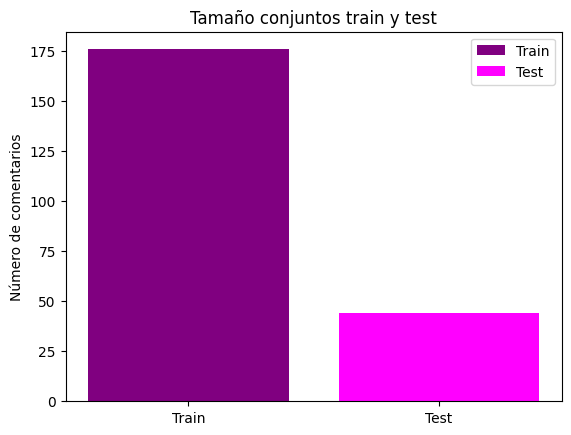

In [149]:
tam_train = len(muestra_train)
tam_test = len(muestra_test)

plt.bar(['Train','Test'],[tam_train,tam_test], label = ['Train','Test'],color = ['purple','magenta'])
plt.title('Tamaño conjuntos train y test')
plt.ylabel('Número de comentarios')
plt.legend()
plt.show()

In [153]:
#Primero definimos el clasificador al que le haremos el finefuning y los parametros necesarios para el mismo,
#entre ellos, las etiquetas de "ida y de vuelta" de la clasificacion
clasificador = AutoModelForSequenceClassification.from_pretrained(
    modelo,
    num_labels = 5,
    id2label= {1:'Negativo',2:'Parcialmente Negativo', 3:'Neutral',4:'Parcialmente Positivo', 5:'Postivo'},
    label2id={'Negativo':1,'Parcialmente Negativo':2, 'Neutral': 3, 'Parcialmente Positivo': 4, 'Positivo':5}
)

# Contar parámetros antes de LoRA
total_params = sum(p.numel() for p in clasificador.parameters())
print(f"\nModelo base cargado.")
print(f"Parámetros totales: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Arquitectura: {clasificador.config.num_hidden_layers} capas × "
      f"{clasificador.config.hidden_size}d × "
      f"{clasificador.config.num_attention_heads} cabezas")


#Ahora, configuramos LORA
lora_config = LoraConfig(
    task_type = TaskType.SEQ_CLS,   # clasificación de secuencias
    r=8,              # rango: dimensión de las matrices B y A
                      # valores típicos: 4, 8, 16, 32, 64
                      # mayor r = más capacidad, más parámetros
    lora_alpha=16,    # escala: controla cuánto pesa ΔW vs W original
                      # regla general: lora_alpha = 2 * r
                      # el peso efectivo es (lora_alpha / r) * BA
    lora_dropout=0.1, # dropout aplicado a las capas LoRA (regularización)
    bias='none',      # no adaptar los sesgos (más eficiente)
    target_modules=[  # ¿en qué capas de BERT aplicar LoRA?
        'query',      # proyección Q en self-attention
        'value',      # proyección V en self-attention
        # 'key', 'dense' — se pueden agregar para más capacidad
    ],
)

#El fine tuning lo hacemos con lora a traves de peft:
#Parameter-Efficient Fine-Tuning (PEFT) methods enable efficient adaptation of large pretrained models 
#to various downstream applications by only fine-tuning a small number of (extra) model parameters 
#instead of all the model's parameters. This significantly decreases the computational and storage costs. 
#Recent state-of-the-art PEFT techniques achieve performance comparable to fully fine-tuned models.
clasificador_peft = get_peft_model(clasificador, lora_config)

#---------------------------------------------------------------------------------------------------------------------
#Incluir esta parte solo para exposicion
#---------------------------------------------------------------------------------------------------------------------
# Podemos ver cuantos parametros se estan entrenando ahora
'''
clasificador.print_trainable_parameters()

# Desglose detallado
total = sum(p.numel() for p in clasificador.parameters())
entrenables = sum(p.numel() for p in clasificador.parameters() if p.requires_grad)
congelados = total - entrenables

print(f"\nDesglose:")
print(f"  Parámetros totales:      {total:>12,}")
print(f"  Parámetros congelados:   {congelados:>12,}  ({congelados/total*100:.1f}%)")
print(f"  Parámetros entrenables:  {entrenables:>12,}  ({entrenables/total*100:.1f}%)")
print(f"\n→ Solo se actualizan {entrenables/total*100:.1f}% de los parámetros en cada paso.")
print(f"→ El modelo base permanece intacto — conocimiento preentrenado preservado.")
'''

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Modelo base cargado.
Parámetros totales: 167,360,261 (167.4M)
Arquitectura: 12 capas × 768d × 12 cabezas


'\nclasificador.print_trainable_parameters()\n\n# Desglose detallado\ntotal = sum(p.numel() for p in clasificador.parameters())\nentrenables = sum(p.numel() for p in clasificador.parameters() if p.requires_grad)\ncongelados = total - entrenables\n\nprint(f"\nDesglose:")\nprint(f"  Parámetros totales:      {total:>12,}")\nprint(f"  Parámetros congelados:   {congelados:>12,}  ({congelados/total*100:.1f}%)")\nprint(f"  Parámetros entrenables:  {entrenables:>12,}  ({entrenables/total*100:.1f}%)")\nprint(f"\n→ Solo se actualizan {entrenables/total*100:.1f}% de los parámetros en cada paso.")\nprint(f"→ El modelo base permanece intacto — conocimiento preentrenado preservado.")\n'

In [154]:
#Definimos las metricas con las que evaluaremos el modelo
def metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predicciones, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predicciones, average='weighted', zero_division=0)
    accuracy = (predicciones == labels).mean()
    bal_accuracy = balanced_accuracy_score(labels,predicciones)
    return {
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'accuracy': accuracy,
        
    }

In [159]:
#Una especie de preprocesado (o cargado) del tokenizador para 
#utilizarlo despues en el tuneo
colador = DataCollatorForTokenClassification(tokenizer = tokenizer)


training_args = TrainingArguments(
    output_dir = MODELOS_PATH,
#    label_names = ['rango_humano'],

    # Épocas y batch
    num_train_epochs=3,              # 3 épocas suele ser suficiente para LoRA
    per_device_train_batch_size=16,  # ejemplos por paso en GPU
    per_device_eval_batch_size=32,

    # Learning rate
    learning_rate=2e-4,              # más alto que full FT (1e-5 a 5e-5)
                                     # LoRA puede tolerar LR más altos
    lr_scheduler_type='cosine',      # decae suavemente hasta 0
    warmup_steps=0.1,                # 10% de pasos para calentamiento

    # Evaluación y guardado
    eval_strategy='epoch',           # evaluar al final de cada época
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,

    # Eficiencia
    fp16=torch.cuda.is_available(),  # precisión mixta si hay GPU
    dataloader_num_workers=2,

    # Logging
    logging_steps=50,
    report_to='none',                # desactivar wandb/tensorboard
)

# Mover modelo al dispositivo
if device == 'cuda':
    model = model.to('cuda')

trainer = Trainer(
    model = clasificador,
    args = training_args,
    train_dataset = muestra_train,
    eval_dataset = muestra_eval,
    data_collator = colador,
    compute_metrics = metricas,
)

In [160]:
#Finalmente entrenamos
resultado_entrenamiento = trainer.train()

'''
clasificador = AutoModelForSequenceClassification.from_pretrained(
    modelo,
    num_labels = len(pd.unique(muestra['rango_humano'])),
    id2label= {1:'Negativo',2:'Parcialmente Negativo', 3:'Neutral',4:'Parcialmente Positivo', 5:'Postivo'},
    label2id={'Negativo':1,'Parcialmente Negativo':2, 'Neutral': 3, 'Parcialmente Positivo': 4, 'Positivo':5}
)
'''

print(f"\nEntrenamiento completo.")
print(f"Tiempo total: {resultado_entrenamiento.metrics['train_runtime']:.0f}s")
print(f"Pasos/segundo: {resultado_entrenamiento.metrics['train_steps_per_second']:.2f}")

ValueError: Expected input batch_size (16) to match target batch_size (2464).

In [ ]:
#k-cross validation para fine tuning
#aun no implementado
def kfold_cross_validation(df, k=5, shuffle=True, random_state=None, stratify=False):
    """
    Genera particiones para k-fold cross validation.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame a particionar
    k : int
        Número de folds (particiones)
    shuffle : bool
        Si mezclar los datos antes de particionar
    random_state : int
        Semilla para reproducibilidad
    stratify : bool o Series
        Si es True, usa la primera columna como estratificación
        Si es Series, usa esa columna para estratificar
    
    Retorna:
    --------
    list : Lista de tuplas (train_indices, test_indices)
    """
    
    if stratify:
        # Obtener etiquetas para estratificación
        if isinstance(stratify, bool):
            y = df.iloc[:, 1]  # Usa primera columna
        else:
            y = df[stratify]
        kfold = StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=random_state)
    else:
        kfold = KFold(n_splits=k, shuffle=shuffle, random_state=random_state)
    
    # Generar folds
    folds = list(kfold.split(df, y if stratify else None))
    
    return folds

# K-Fold simple

folds = kfold_cross_validation(muestra, k=5, shuffle=True, random_state=42)
#print(folds)


etiqueta_train = []
confianza_train = []


for i, (train_idx, test_idx) in enumerate(folds):
    #print(f"Fold {i+1}: Train={len(train_idx)}, Test={len(test_idx)}")
    #print(train_idx)
    #print(test_idx)
    # Obtenemos los DataFrames
    train_df = muestra.iloc[train_idx]
    test_df = muestra.iloc[test_idx]
    
    

    pass

In [136]:
print("Estructura del dataset:")
print(muestra_ds)
print("\nPrimer ejemplo:")
print(muestra_ds[0])
print("\nTipo de labels:", type(muestra_ds[0]["labels"]))
if isinstance(muestra_ds[0]["labels"], torch.Tensor):
    print("Shape de labels:", muestra_ds[0]["labels"].shape)
    print("Dimensiones:", muestra_ds[0]["labels"].dim())

Estructura del dataset:
Dataset({
    features: ['comentario', 'rango_humano', 'labels', '__index_level_0__'],
    num_rows: 220
})

Primer ejemplo:
{'comentario': 'cuál es el más cercado para rayar el nombre de mi rukaleta', 'rango_humano': 3.0, 'labels': 3, '__index_level_0__': 0}

Tipo de labels: <class 'int'>
